# Linear Regression Model for all three states combined

## Import libraries and load data

In [1]:
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
!pip install lmdiag --upgrade
import lmdiag
import numpy as np

In [2]:
# Load the data
df = pd.read_csv("classification_dataset_250.csv")
print(df.head())

# Split the data into features (X) and target (y),
# removing all non-continuous columns and columns
# used for classification classes
X = df.drop(columns=["county_fips","state","county_name","volatility_class",
                     "vol_quintile_num","vol_binary","vol_z_abs_sum"])
y = df["vol_z_abs_sum"]

# Split the data into training and testing sets
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.2, random_state=42)

   county_fips state     county_name  median_age  pct_black  pct_asian  \
0        26001    MI   Alcona County    2.930040  -0.717205  -0.478302   
1        26003    MI    Alger County    0.921851  -0.186118  -0.614575   
2        26005    MI  Allegan County   -0.570473  -0.674143  -0.369456   
3        26007    MI   Alpena County    0.682342  -0.690351  -0.659864   
4        26009    MI   Antrim County    1.419292  -0.719975  -0.589222   

   pct_two_or_more_races  pct_hispanic  pct_hs_or_higher  pct_bachelors_plus  \
0              -0.774127     -0.961247          0.689257           -0.453399   
1               0.117859     -0.947839          0.962117           -0.494054   
2               0.585920      0.367723          0.543613            0.125959   
3              -0.319376     -0.969760          0.590553           -0.765715   
4              -0.684695     -0.861257          1.195958            0.850923   

   ...  race_entropy_norm  log_total_population  log_population_density  \

## Feature Selection

I tried four different approaches to narrow down what features to use in the linear model: forward select with $R^2$ scoring, backward select with $R^2$ scoring, forward select with mean absolute error scoring, and backward select with mean absolute error scoring. I then used the model with the lowest AIC/BIC scores.

## Build linear model for vol_z_abs_sum using forward select approach, r2 scoring

In [3]:
# Build step forward feature selection (using Cross-Validation)
sfs1 = SFS(LinearRegression(),
          k_features="best",
          forward=True,
          scoring="r2",
          cv=5)

sfs1 = sfs1.fit(XTrain, yTrain)

# Get the optimal features
optimalFeatures1 = list(sfs1.k_feature_names_)
print(f"Optimal features: {optimalFeatures1}")

# Form the final optimal model using statsmodels to get a detailed summary
XOptimal1 = XTrain[optimalFeatures1]
# Add a constant (intercept) to the predictors
XOptimal1 = sm.add_constant(XOptimal1)

# Fit the OLS model
optimalModel1 = sm.OLS(yTrain, XOptimal1).fit()

# Print the model summary
print("\nOptimal Linear Regression Model Summary:")
print(optimalModel1.summary())

Optimal features: ['pct_black', 'pct_income_under_25k', 'pct_owner_occupied', 'pct_carpool', 'pct_family_households', 'pct_married_couple', 'race_entropy_norm', 'log_population_density', 'log_median_gross_rent']

Optimal Linear Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:          vol_z_abs_sum   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     14.59
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           7.66e-18
Time:                        14:03:51   Log-Likelihood:                -321.81
No. Observations:                 200   AIC:                             663.6
Df Residuals:                     190   BIC:                             696.6
Df Model:                           9                                         
Covariance Type:            nonrobu

## Build linear model for vol_z_abs_sum using backward select approach, r2 scoring

In [4]:
# Build step backward feature selection (using Cross-Validation)
sfs2 = SFS(LinearRegression(),
          k_features="best",
          forward=False,
          scoring="r2",
          cv=5)

sfs2 = sfs2.fit(XTrain, yTrain)

# Get the optimal features
optimalFeatures2 = list(sfs2.k_feature_names_)
print(f"Optimal features: {optimalFeatures2}")

# Form the final optimal model using statsmodels to get a detailed summary
XOptimal2 = XTrain[optimalFeatures2]
# Add a constant (intercept) to the predictors
XOptimal2 = sm.add_constant(XOptimal2)

# Fit the OLS model
optimalModel2 = sm.OLS(yTrain, XOptimal2).fit()

# Print the model summary
print("\nOptimal Linear Regression Model Summary:")
print(optimalModel2.summary())

Optimal features: ['pct_black', 'pct_bachelors_plus', 'pct_income_under_25k', 'pct_owner_occupied', 'race_entropy_norm', 'log_median_home_value', 'log_median_gross_rent']

Optimal Linear Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:          vol_z_abs_sum   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     18.19
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.82e-18
Time:                        14:04:05   Log-Likelihood:                -323.46
No. Observations:                 200   AIC:                             662.9
Df Residuals:                     192   BIC:                             689.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                       

## Build linear model for vol_z_abs_sum using forward select approach, mean_absolute_error scoring

In [5]:
# Build step forward feature selection (using Cross-Validation)
sfs3 = SFS(LinearRegression(),
          k_features="best",
          forward=True,
          scoring="neg_mean_absolute_error",
          cv=5)

sfs3 = sfs3.fit(XTrain, yTrain)

# Get the optimal features
optimalFeatures3 = list(sfs3.k_feature_names_)
print(f"Optimal features: {optimalFeatures3}")

# Form the final optimal model using statsmodels to get a detailed summary
XOptimal3 = XTrain[optimalFeatures3]
# Add a constant (intercept) to the predictors
XOptimal3 = sm.add_constant(XOptimal3)

# Fit the OLS model
optimalModel3 = sm.OLS(yTrain, XOptimal3).fit()

# Print the model summary
print("\nOptimal Linear Regression Model Summary:")
print(optimalModel3.summary())

Optimal features: ['pct_black', 'pct_bachelors_plus', 'pct_income_under_25k', 'pct_owner_occupied', 'pct_drive_alone', 'race_entropy_norm', 'log_median_home_value', 'log_median_gross_rent']

Optimal Linear Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:          vol_z_abs_sum   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     16.65
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.28e-18
Time:                        14:04:13   Log-Likelihood:                -321.43
No. Observations:                 200   AIC:                             660.9
Df Residuals:                     191   BIC:                             690.5
Df Model:                           8                                         
Covariance Type:            nonrobust                    

## Build linear model for vol_z_abs_sum using backward select approach, mean_absolute_error scoring

In [6]:
# Build step backward feature selection (using Cross-Validation)
sfs4 = SFS(LinearRegression(),
          k_features="best",
          forward=False,
          scoring="neg_mean_absolute_error",
          cv=5)

sfs4 = sfs4.fit(XTrain, yTrain)

# Get the optimal features
optimalFeatures4 = list(sfs4.k_feature_names_)
print(f"Optimal features: {optimalFeatures4}")

# Form the final optimal model using statsmodels to get a detailed summary
XOptimal4 = XTrain[optimalFeatures4]
# Add a constant (intercept) to the predictors
XOptimal4 = sm.add_constant(XOptimal4)

# Fit the OLS model
optimalModel4 = sm.OLS(yTrain, XOptimal4).fit()

# Print the model summary
print("\nOptimal Linear Regression Model Summary:")
print(optimalModel4.summary())

Optimal features: ['pct_black', 'pct_bachelors_plus', 'pct_income_under_25k', 'pct_owner_occupied', 'pct_drive_alone', 'race_entropy_norm', 'log_median_home_value', 'log_median_gross_rent']

Optimal Linear Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:          vol_z_abs_sum   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     16.65
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.28e-18
Time:                        14:04:18   Log-Likelihood:                -321.43
No. Observations:                 200   AIC:                             660.9
Df Residuals:                     191   BIC:                             690.5
Df Model:                           8                                         
Covariance Type:            nonrobust                    

## Compare Results

Based on an average AIC and BIC score, the best model was produced using mean absolute error as a scoring method. Both the forward select and backward select methods produced the same model. The selected features are pct_black, pct_bachelors_plus, pct_income_under_25k, pct_owner_occupied, pct_drive_alone, race_entropy_norm, log_median_home_value, and log_median_gross_rent.

## Test collinearity assumption for selected model

To test the collinearity assumption, I created a correlation matrix and calculated the Variance Inflation Factors of the selected features. There are some values in the correlation matrix that are a little concerning, but due to the social nature of the study and the highest VIF score being about 5.34, this passes the collinearity test. I also tried removing log_median_gross_rent, the predictor with the VIF above 5.0, from the model, but it resulted in a higher AIC and BIC, backing up my decision to leave it in.

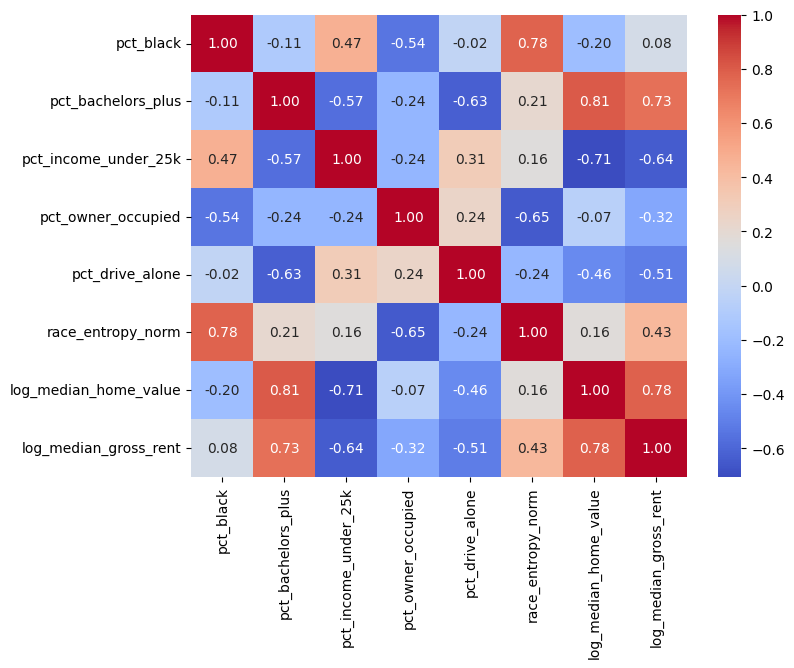

In [7]:
# Create correlation matrix
corrDF = XTrain[optimalFeatures3]
corrMatrix = corrDF.corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6)) # Adjust figure size
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [8]:
# Create a DataFrame to store VIF values
vifData = pd.DataFrame()
vifData["feature"] = XOptimal3.columns
vifData["VIF"] = [variance_inflation_factor(XOptimal3.values, i) for i in range(XOptimal3.shape[1])]
print(vifData)

                 feature       VIF
0                  const  1.010948
1              pct_black  3.954513
2     pct_bachelors_plus  4.184135
3   pct_income_under_25k  3.973231
4     pct_owner_occupied  2.222300
5        pct_drive_alone  1.750247
6      race_entropy_norm  4.363505
7  log_median_home_value  4.786707
8  log_median_gross_rent  5.337186


## Generate diagnostic plots to test other assumptions

First, I created a residuals vs fitted values plot to check the linearity assumption. There's no obvious pattern and the residuals are pretty evenly spread, so it passes the linearity test.

Next, the points in the QQ plot stay pretty consistent with the line x = y,so the model passes the normality assumption. However, there are a couple of points that stray a bit further from the line, indicating potential outliers.

For the Scale-Location plot, the fitted line does have a slight upward trend, indicating the residuals get slightly larger as the predicted values increase, so the homoscedasticity assumption might not be completely met. This isn't severe enough to discount the model though.

For the Residuals vs Leverage plot, no points cross the threshold marked by the dashed line, so no points are breaking the model. There's a single point to the far right with high leverage, but its residual is close to 0. All the data points with high residuals have low enough leverage that they aren't throwing off the model.

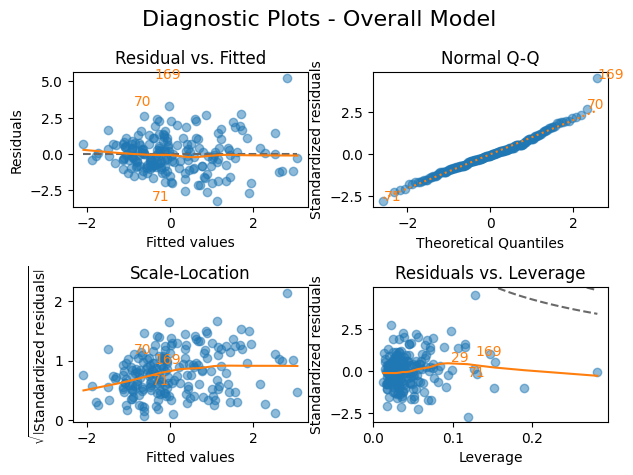

In [9]:
# Generate diagnostic plots
fig = lmdiag.plot(optimalModel3)
fig.suptitle("Diagnostic Plots - Overall Model", fontsize=16)
plt.tight_layout()
plt.show()

## Test model predictions on test data set

In [10]:
import math
XTest = XTest[optimalFeatures3]
XTest = sm.add_constant(XTest)
yPred = optimalModel3.predict(XTest)

# Evaluate the model
mse = mean_squared_error(yTest, yPred)
rmse = math.sqrt(mse)
r2 = r2_score(yTest, yPred)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Coefficient of Determination (R-squared): {r2}")

Root Mean Squared Error (RMSE): 1.1218780421120471
Coefficient of Determination (R-squared): 0.23617550295640755


# Linear Regression Model for individual states

Next, I used the forward select approach with mean_absolute_error scoring to produce the optimal linear models for each of the three states individually, so that we could compare them to each other and the overall model created above to see which, if any, features carry over across state lines.

## Linear Regression Model: MI

In [11]:
# Filter original DF so only MI rows remain
dfMI = df[df["state"] == "MI"]

# Split the data into features (X) and target (y),
# removing all non-continuous columns
XMI = dfMI.drop(columns=["county_fips","state","county_name","volatility_class",
                     "vol_quintile_num","vol_binary","vol_z_abs_sum"])
yMI = dfMI["vol_z_abs_sum"]

# Split the data into training and testing sets
XTrainMI, XTestMI, yTrainMI, yTestMI = train_test_split(XMI, yMI,
                                                        test_size=0.2,
                                                        random_state=42)

In [12]:
# Build step forward feature selection (using Cross-Validation)
sfsMI = SFS(LinearRegression(),
          k_features="best",
          forward=True,
          scoring="neg_mean_absolute_error",
          cv=5)

sfsMI = sfsMI.fit(XTrainMI, yTrainMI)

# Get the optimal features
optimalFeaturesMI = list(sfsMI.k_feature_names_)
print(f"Optimal features: {optimalFeaturesMI}")

# Form the final optimal model using statsmodels to get a detailed summary
XOptimalMI = XTrainMI[optimalFeaturesMI]
# Add a constant (intercept) to the predictors
XOptimalMI = sm.add_constant(XOptimalMI)

# Fit the OLS model
optimalModelMI = sm.OLS(yTrainMI, XOptimalMI).fit()

# Print the model summary
print("\nOptimal Linear Regression Model Summary:")
print(optimalModelMI.summary())

Optimal features: ['pct_bachelors_plus', 'pct_carpool']

Optimal Linear Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:          vol_z_abs_sum   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     15.59
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           3.16e-06
Time:                        14:04:26   Log-Likelihood:                -82.317
No. Observations:                  66   AIC:                             170.6
Df Residuals:                      63   BIC:                             177.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

### Diagnostic plots and collinearity checks for MI model

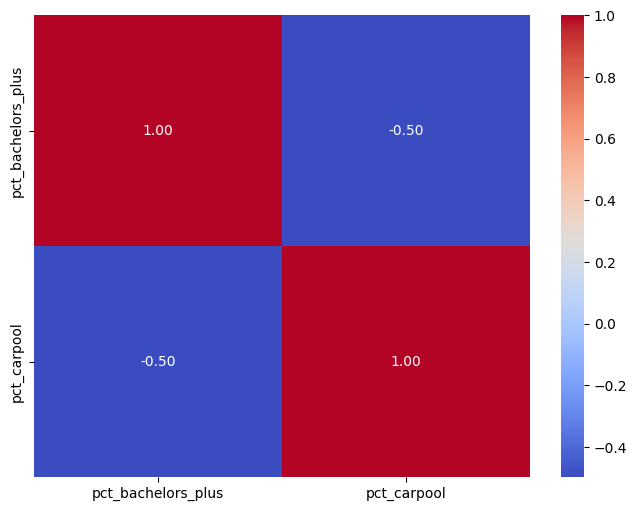

              feature       VIF
0               const  1.009680
1  pct_bachelors_plus  1.329726
2         pct_carpool  1.329726


In [13]:
# Create correlation matrix
corrDFMI = XTrainMI[optimalFeaturesMI]
corrMatrixMI = corrDFMI.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6)) # Adjust figure size
sns.heatmap(corrMatrixMI, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

# Store VIF values then display them
vifDataMI = pd.DataFrame()
vifDataMI["feature"] = XOptimalMI.columns
vifDataMI["VIF"] = [variance_inflation_factor(XOptimalMI.values, i) for i in range(XOptimalMI.shape[1])]
print(vifDataMI)

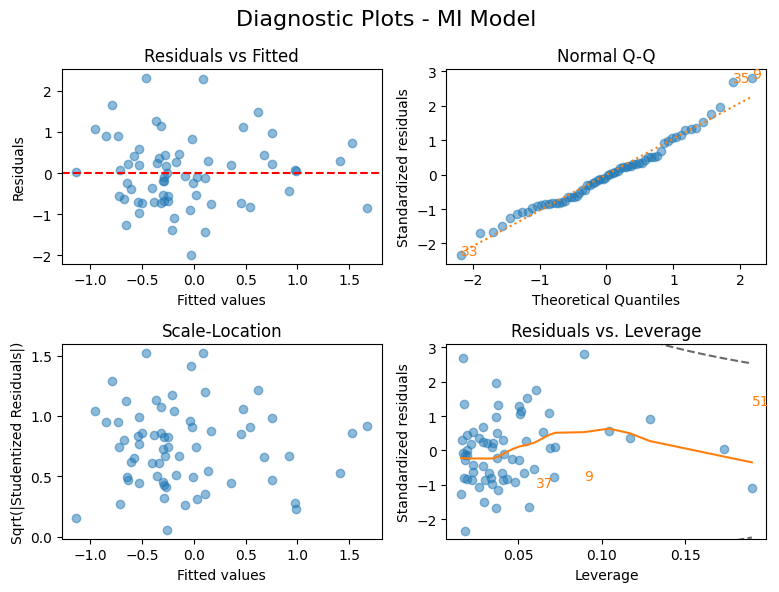

In [14]:
# Generate diagnostic plots
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
fig.suptitle("Diagnostic Plots - MI Model", fontsize=16)
# Plot 1: Residuals vs Fitted
ax[0, 0].scatter(optimalModelMI.fittedvalues, optimalModelMI.resid, alpha=0.5)
ax[0, 0].axhline(y=0, color="r", linestyle="--")
ax[0, 0].set_title("Residuals vs Fitted")
ax[0, 0].set_xlabel("Fitted values")
ax[0, 0].set_ylabel("Residuals")
# Plot 2: Normal Q-Q
lmdiag.q_q(optimalModelMI,ax=ax[0,1])
# Plot 3: Scale-Location
ax[1, 0].scatter(optimalModelMI.fittedvalues, np.sqrt(np.abs(optimalModelMI.resid)), alpha=0.5)
ax[1, 0].set_title("Scale-Location")
ax[1, 0].set_xlabel("Fitted values")
ax[1, 0].set_ylabel("Sqrt(|Studentized Residuals|)")
# Plot 4: Residuals vs Leverage
lmdiag.resid_lev(optimalModelMI,ax=ax[1,1])
# Display plots
plt.tight_layout()
plt.show()

### Test predictions for MI model

In [15]:
XTestMI = XTestMI[optimalFeaturesMI]
XTestMI = sm.add_constant(XTestMI)
yPredMI = optimalModelMI.predict(XTestMI)

# Evaluate the model
mseMI = mean_squared_error(yTestMI, yPredMI)
rmseMI = math.sqrt(mseMI)
r2MI = r2_score(yTestMI, yPredMI)

print(f"Root Mean Squared Error (MSE): {rmseMI}")
print(f"Coefficient of Determination (R-squared): {r2MI}")

Root Mean Squared Error (MSE): 0.895867850157752
Coefficient of Determination (R-squared): 0.3104790154637461


## Linear Regression Model: NC

In [16]:
# Filter original DF so only NC rows remain
dfNC = df[df["state"] == "NC"]

# Split the data into features (X) and target (y),
# removing all non-continuous columns
XNC = dfNC.drop(columns=["county_fips","state","county_name","volatility_class",
                     "vol_quintile_num","vol_binary","vol_z_abs_sum"])
yNC = dfNC["vol_z_abs_sum"]

# Split the data into training and testing sets
XTrainNC, XTestNC, yTrainNC, yTestNC = train_test_split(XNC, yNC,
                                                        test_size=0.2,
                                                        random_state=92)

In [17]:
# Build step forward feature selection (using Cross-Validation)
sfsNC = SFS(LinearRegression(),
          k_features="best",
          forward=True,
          scoring="neg_mean_absolute_error",
          cv=5)

sfsNC = sfsNC.fit(XTrainNC, yTrainNC)

# Get the optimal features
optimalFeaturesNC = list(sfsNC.k_feature_names_)
print(f"Optimal features: {optimalFeaturesNC}")

# Form the final optimal model using statsmodels to get a detailed summary
XOptimalNC = XTrainNC[optimalFeaturesNC]
# Add a constant (intercept) to the predictors
XOptimalNC = sm.add_constant(XOptimalNC)

# Fit the OLS model
optimalModelNC = sm.OLS(yTrainNC, XOptimalNC).fit()

# Print the model summary
print("\nOptimal Linear Regression Model Summary:")
print(optimalModelNC.summary())

Optimal features: ['pct_black', 'pct_hispanic', 'pct_below_poverty', 'pct_carpool', 'log_median_household_income']

Optimal Linear Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:          vol_z_abs_sum   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     11.38
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           3.65e-08
Time:                        14:04:32   Log-Likelihood:                -133.67
No. Observations:                  80   AIC:                             279.3
Df Residuals:                      74   BIC:                             293.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err    

### Test predictions for NC model

In [18]:
XTestNC = XTestNC[optimalFeaturesNC]
XTestNC = sm.add_constant(XTestNC)
yPredNC = optimalModelNC.predict(XTestNC)

# Evaluate the model
mseNC = mean_squared_error(yTestNC, yPredNC)
rmseNC = math.sqrt(mseNC)
r2NC = r2_score(yTestNC, yPredNC)

print(f"Root Mean Squared Error (MSE): {rmseNC}")
print(f"Coefficient of Determination (R-squared): {r2NC}")

Root Mean Squared Error (MSE): 2.329406762384627
Coefficient of Determination (R-squared): -0.03403913575283202


### Diagnostic plots and collinearity checks for NC model

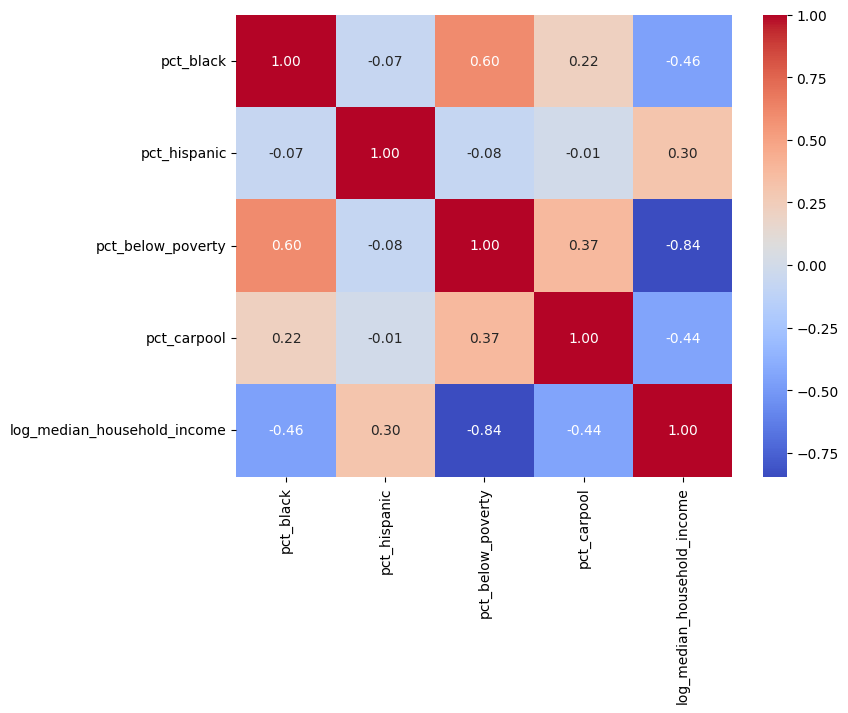

                       feature       VIF
0                        const  1.638313
1                    pct_black  1.595961
2                 pct_hispanic  1.291152
3            pct_below_poverty  4.956532
4                  pct_carpool  1.273920
5  log_median_household_income  4.831589


In [19]:
# Create correlation matrix
corrDFNC = XTrainNC[optimalFeaturesNC]
corrMatrixNC = corrDFNC.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6)) # Adjust figure size
sns.heatmap(corrMatrixNC, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

# Store VIF values then display them
vifDataNC = pd.DataFrame()
vifDataNC["feature"] = XOptimalNC.columns
vifDataNC["VIF"] = [variance_inflation_factor(XOptimalNC.values, i) for i in range(XOptimalNC.shape[1])]
print(vifDataNC)

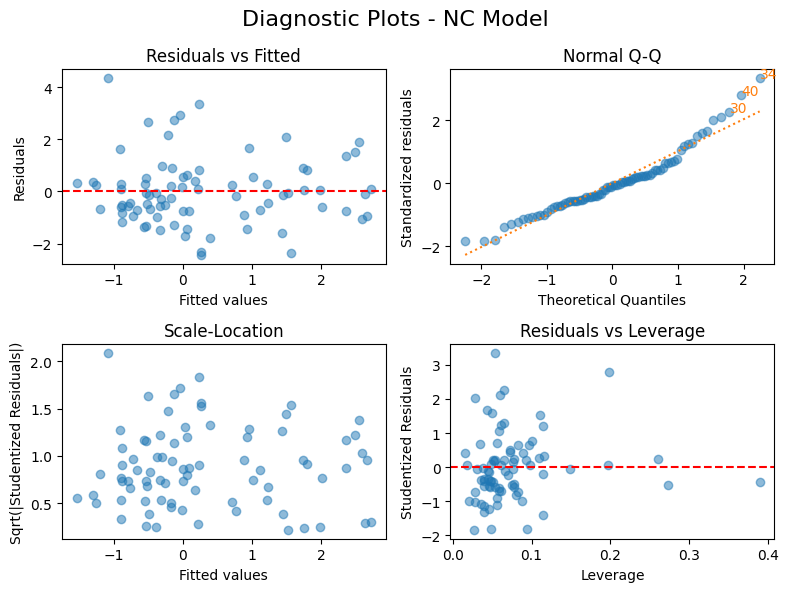

In [20]:
# Generate diagnostic plots
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
fig.suptitle("Diagnostic Plots - NC Model", fontsize=16)
# Plot 1: Residuals vs Fitted
ax[0, 0].scatter(optimalModelNC.fittedvalues, optimalModelNC.resid, alpha=0.5)
ax[0, 0].axhline(y=0, color="r", linestyle="--")
ax[0, 0].set_title("Residuals vs Fitted")
ax[0, 0].set_xlabel("Fitted values")
ax[0, 0].set_ylabel("Residuals")
# Plot 2: Normal Q-Q
lmdiag.q_q(optimalModelNC,ax=ax[0,1])
# Plot 3: Scale-Location
ax[1, 0].scatter(optimalModelNC.fittedvalues, np.sqrt(np.abs(optimalModelNC.resid)), alpha=0.5)
ax[1, 0].set_title("Scale-Location")
ax[1, 0].set_xlabel("Fitted values")
ax[1, 0].set_ylabel("Sqrt(|Studentized Residuals|)")
# Plot 4: Residuals vs Leverage
ax[1, 1].scatter(optimalModelNC.get_influence().hat_matrix_diag,
                 optimalModelNC.get_influence().resid_studentized_internal, alpha=0.5)
ax[1, 1].axhline(y=0, color="r", linestyle="--")
ax[1, 1].set_title("Residuals vs Leverage")
ax[1, 1].set_xlabel("Leverage")
ax[1, 1].set_ylabel("Studentized Residuals")
# Display plots
plt.tight_layout()
plt.show()

## Linear Regression Model: PA

In [21]:
# Filter original DF so only PA rows remain
dfPA = df[df["state"] == "PA"]

# Split the data into features (X) and target (y),
# removing all non-continuous columns
XPA = dfPA.drop(columns=["county_fips","state","county_name","volatility_class",
                     "vol_quintile_num","vol_binary","vol_z_abs_sum"])
yPA = dfPA["vol_z_abs_sum"]

# Split the data into training and testing sets
XTrainPA, XTestPA, yTrainPA, yTestPA = train_test_split(XPA, yPA,
                                                        test_size=0.2,
                                                        random_state=53)

In [22]:
# Build step forward feature selection (using Cross-Validation)
sfsPA = SFS(LinearRegression(),
          k_features="best",
          forward=True,
          scoring="neg_mean_absolute_error",
          cv=5)

sfsPA = sfsPA.fit(XTrainPA, yTrainPA)

# Get the optimal features
optimalFeaturesPA = list(sfsPA.k_feature_names_)
print(f"Optimal features: {optimalFeaturesPA}")

# Form the final optimal model using statsmodels to get a detailed summary
XOptimalPA = XTrainPA[optimalFeaturesPA]
# Add a constant (intercept) to the predictors
XOptimalPA = sm.add_constant(XOptimalPA)

# Fit the OLS model
optimalModelPA = sm.OLS(yTrainPA, XOptimalPA).fit()

# Print the model summary
print("\nOptimal Linear Regression Model Summary:")
print(optimalModelPA.summary())

Optimal features: ['median_age', 'unemployment_rate', 'race_entropy_norm', 'log_median_gross_rent']

Optimal Linear Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:          vol_z_abs_sum   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     24.83
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           3.52e-11
Time:                        14:04:39   Log-Likelihood:                -62.337
No. Observations:                  53   AIC:                             134.7
Df Residuals:                      48   BIC:                             144.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|   

### Test predictions for PA model


In [23]:
XTestPA = XTestPA[optimalFeaturesPA]
XTestPA = sm.add_constant(XTestPA)
yPredPA = optimalModelPA.predict(XTestPA)

# Evaluate the model
msePA = mean_squared_error(yTestPA, yPredPA)
rmsePA = math.sqrt(msePA)
r2PA = r2_score(yTestPA, yPredPA)

print(f"Root Mean Squared Error (MSE): {rmsePA}")
print(f"Coefficient of Determination (R-squared): {r2PA}")

Root Mean Squared Error (MSE): 1.0133858672788705
Coefficient of Determination (R-squared): 0.21608145049203498


### Diagnostic plots and collinearity checks for PA model

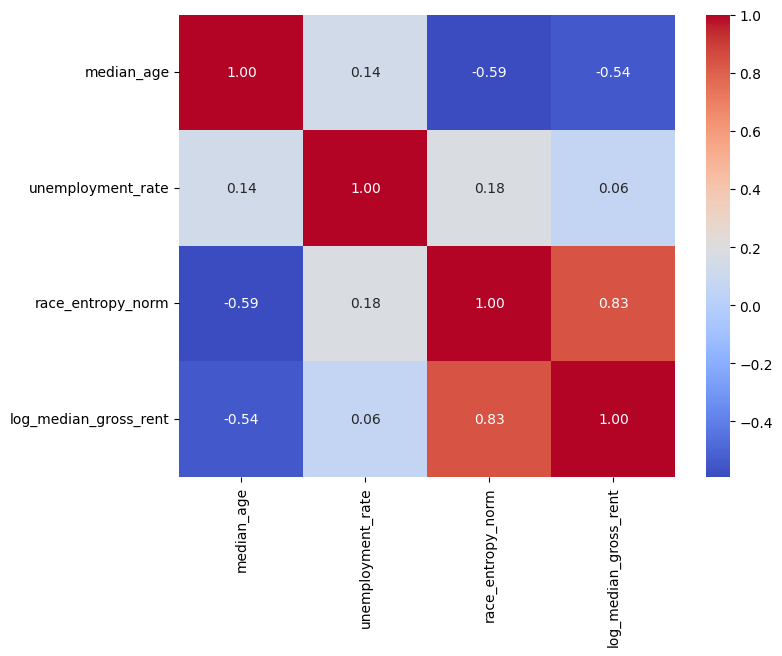

                 feature       VIF
0                  const  2.192327
1             median_age  1.698169
2      unemployment_rate  1.163052
3      race_entropy_norm  3.997422
4  log_median_gross_rent  3.377264


In [24]:
# Create correlation matrix
corrDFPA = XTrainPA[optimalFeaturesPA]
corrMatrixPA = corrDFPA.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6)) # Adjust figure size
sns.heatmap(corrMatrixPA, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

# Store VIF values then display them
vifDataPA = pd.DataFrame()
vifDataPA["feature"] = XOptimalPA.columns
vifDataPA["VIF"] = [variance_inflation_factor(XOptimalPA.values, i) for i in range(XOptimalPA.shape[1])]
print(vifDataPA)

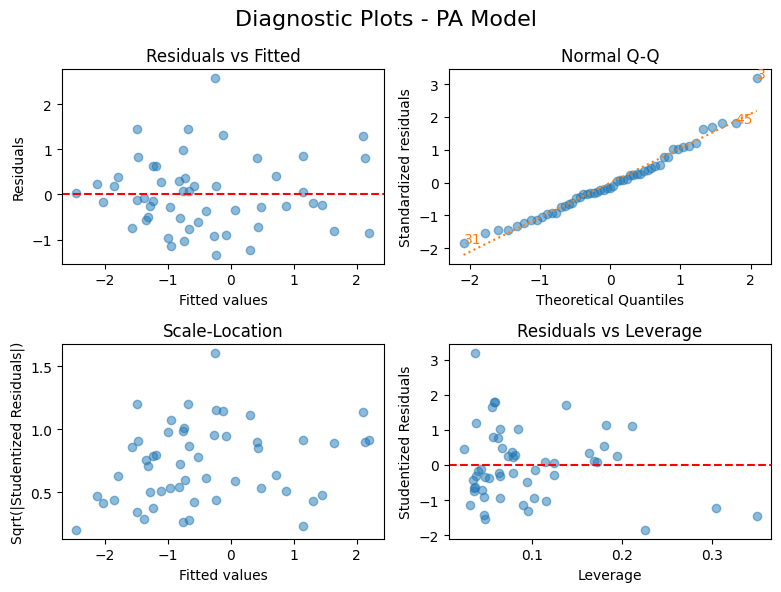

In [25]:
# Generate diagnostic plots
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
fig.suptitle("Diagnostic Plots - PA Model", fontsize=16)
# Plot 1: Residuals vs Fitted
ax[0, 0].scatter(optimalModelPA.fittedvalues, optimalModelPA.resid, alpha=0.5)
ax[0, 0].axhline(y=0, color="r", linestyle="--")
ax[0, 0].set_title("Residuals vs Fitted")
ax[0, 0].set_xlabel("Fitted values")
ax[0, 0].set_ylabel("Residuals")
# Plot 2: Normal Q-Q
lmdiag.q_q(optimalModelPA,ax=ax[0,1])
# Plot 3: Scale-Location
ax[1, 0].scatter(optimalModelPA.fittedvalues, np.sqrt(np.abs(optimalModelPA.resid)), alpha=0.5)
ax[1, 0].set_title("Scale-Location")
ax[1, 0].set_xlabel("Fitted values")
ax[1, 0].set_ylabel("Sqrt(|Studentized Residuals|)")
# Plot 4: Residuals vs Leverage
ax[1, 1].scatter(optimalModelPA.get_influence().hat_matrix_diag,
                 optimalModelPA.get_influence().resid_studentized_internal, alpha=0.5)
ax[1, 1].axhline(y=0, color="r", linestyle="--")
ax[1, 1].set_title("Residuals vs Leverage")
ax[1, 1].set_xlabel("Leverage")
ax[1, 1].set_ylabel("Studentized Residuals")
# Display plots
plt.tight_layout()
plt.show()

For all three individual state models, each feature’s VIF score is below 5.0. Therefore all three models pass the collinearity assumption.

Based on its diagnostic plots, we can conclude that the Michigan model satisfies the assumptions reasonably well. The lack of any clear patterns in the Residuals vs Fitted plot shows a linear relationship between the predictors and the response. While there’s a bit of heaviness in the tails, the points on the Q-Q plot are mostly quite close to the x=y line, which suggests the residuals are normally distributed. The points in the Scale-Location plot are randomly scattered, which indicates homoscedasticity. Finally, the lack of points in the upper-right or lower-right corners of the Residuals vs Leverage plot indicates there aren’t any outliers heavily skewing the model.

The North Carolina model does show a few red flags in its diagnostic plots. While the linearity assumption is met based on the lack of patterns in the Residuals vs Fitted plot, the Q-Q plot suggests the residuals have a right-skewed distribution, not a normal one. While there’s some evidence of fanning in the Scale-Location plot, it’s not enough that it doesn’t pass the homoscedasticity assumption. Finally, while there are a few points with high residual values, they don’t have a significant enough leverage to throw off the model.

The diagnostic plots for the Pennsylvania model, meanwhile, suggest it passes the assumptions very well. There’s no pattern in the Residual vs Fitted plot, so it passes the linearity assumption. Outside of observation 3, the points on the Q-Q plot are all right on the x=y line, so the residuals appear to have a normal distribution. The homoscedasticity assumption appears met from the Scale-Location plot, as the range of residual values remains pretty constant as the fitted values increase. Finally, while there are a couple points with high leverage, their residuals are small enough not to throw any flags.


The North Carolina model specifically did not preform well during the test prediction phase. The predictions for the other two states had moderate success, like the overall model.